# Regenerate Result Tables and Figures

This notebook regenerates experimental Tables 3-10 and Figures 2-5 from
the machine-readable repository outputs. It does not read the manuscript.
Tables 3-9 and Figures 2-5 use only internal experiment results. Table 10
additionally uses the published GBC reference metrics recorded in
`reference_inputs/published_gbc_reference.csv`.

Figure 1 is a conceptual framework diagram, not a numerical result, and is
maintained as a separate editable source.


## 1. Connect Google Drive and install the environment


In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research/"
    "LICE_Guided_Model_Refinement_Release_V3"
)
assert PROJECT_ROOT.exists(), f"Release folder not found: {PROJECT_ROOT}"

from importlib.metadata import PackageNotFoundError, version
import os
import sys

PINNED_BINARY_STACK = {
    "numpy": ("numpy", "2.5.1"),
    "pandas": ("pandas", "2.2.3"),
    "scikit-learn": ("sklearn", "1.5.2"),
    "scipy": ("scipy", "1.18.0"),
    "statsmodels": ("statsmodels", "0.14.4"),
}


def installed_version(distribution_name):
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        return None


restart_required = any(
    installed_version(distribution) != required
    or (
        module in sys.modules
        and getattr(sys.modules[module], "__version__", None) != required
    )
    for distribution, (module, required) in PINNED_BINARY_STACK.items()
)

%pip install -q -r "{PROJECT_ROOT / 'requirements.txt'}"

if restart_required:
    print(
        "Pinned packages were installed. Colab will restart now. "
        "After it reconnects, run this setup cell once more and "
        "then continue to the next cell.",
        flush=True,
    )
    os.kill(os.getpid(), 9)

print(f"Release folder: {PROJECT_ROOT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Release folder: /content/drive/MyDrive/Research/LICE_Guided_Model_Refinement_Release_V3


## 2. Load machine-readable inputs


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

RESULTS_DIR = PROJECT_ROOT / "results"
REFERENCE_DIR = PROJECT_ROOT / "reference_inputs"
GENERATED_DIR = PROJECT_ROOT / "generated_outputs"
TABLE_DIR = GENERATED_DIR / "tables"
FIGURE_DIR = GENERATED_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(
    RESULTS_DIR / "metrics_full_precision.csv"
).set_index("Model")
comparison = pd.read_csv(
    RESULTS_DIR / "comparison_vs_baseline_full_precision.csv"
).set_index("Model")
mcnemar_results = pd.read_csv(
    RESULTS_DIR / "mcnemar_results_full_precision.csv"
)
published_reference = pd.read_csv(
    REFERENCE_DIR / "published_gbc_reference.csv"
)

MODEL_ORDER = [
    "Baseline", "M1-Interactions", "M2-Mild", "M2-Balanced",
    "M2-High", "M3-Mild", "M3-Balanced", "M3-High",
]
DISPLAY_NAMES = {
    "Baseline": "M0: baseline TunedGBDT",
    "M1-Interactions": "M1: LICE-derived interaction-only model",
    "M2-Mild": "M2-Mild: LICE-weighted-only",
    "M2-Balanced": "M2-Balanced: LICE-weighted-only",
    "M2-High": "M2-High: LICE-weighted-only",
    "M3-Mild": "M3-Mild: LICE-Interaction + LICE-weighting",
    "M3-Balanced": "M3-Balanced: LICE-Interaction + LICE-weighting",
    "M3-High": "M3-High: LICE-Interaction + LICE-weighting",
}


def markdown_table(frame):
    headers = [str(column) for column in frame.columns]
    output = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in frame.astype(str).itertuples(index=False, name=None):
        output.append("| " + " | ".join(row) + " |")
    return "\n".join(output) + "\n"


def save_table(frame, number, slug):
    stem = f"table_{number}_{slug}"
    frame.to_csv(TABLE_DIR / f"{stem}.csv", index=False)
    (TABLE_DIR / f"{stem}.md").write_text(
        markdown_table(frame), encoding="utf-8"
    )
    return stem


print("Result inputs loaded.")
display(metrics.loc[MODEL_ORDER])


Result inputs loaded.


,Training_Samples,Test_Samples,Weight_Level,Weighted_Training_Samples,Mean_Training_Weight,Maximum_Training_Weight,TN,FP,FN,TP,Accuracy,AUC,Recall,Precision,F1,Kappa,MCC
Model,,,,,,,,,,,,,,,,,
Baseline,55245,13812,NaN,0,1.000000,1.00,4767,1956,1417,5672,0.755792,0.830959,0.800113,0.743576,0.770809,0.510227,0.511797
M1-Interactions,55245,13812,NaN,0,1.000000,1.00,4765,1958,1393,5696,0.757385,0.831701,0.803498,0.744186,0.772706,0.513373,0.515110
M2-Mild,55245,13812,Mild,7174,1.014874,1.15,4666,2057,1326,5763,0.755068,0.830215,0.812950,0.736957,0.773090,0.508412,0.511305
M2-Balanced,55245,13812,Balanced,7174,1.023255,1.25,4621,2102,1265,5824,0.756226,0.830236,0.821555,0.734797,0.775758,0.510537,0.514359
M2-High,55245,13812,High,7174,1.031635,1.35,4567,2156,1240,5849,0.754127,0.829808,0.825081,0.730668,0.775010,0.506171,0.510722
M3-Mild,55245,13812,Mild,7174,1.014874,1.15,4677,2046,1312,5777,0.756878,0.831215,0.814925,0.738464,0.774812,0.512039,0.514977
M3-Balanced,55245,13812,Balanced,7174,1.023255,1.25,4613,2110,1245,5844,0.757095,0.830749,0.824376,0.734725,0.776973,0.512229,0.516328
M3-High,55245,13812,High,7174,1.031635,1.35,4561,2162,1221,5868,0.755068,0.829944,0.827761,0.730760,0.776242,0.508014,0.512839


## 3. Tables 3-10

The tables are calculated from unrounded inputs. Presentation metrics are
formatted to four decimal places; relative false-negative reductions and
percentage-point comparisons are formatted to two decimal places.


In [3]:
def f4(value):
    return f"{float(value):.4f}"


def f2(value):
    return f"{float(value):.2f}"


table_3_rows = []
for model in MODEL_ORDER:
    row = metrics.loc[model]
    table_3_rows.append({
        "Variant": DISPLAY_NAMES[model],
        "TP": int(row.TP), "TN": int(row.TN),
        "FP": int(row.FP), "FN": int(row.FN),
        "Accuracy": f4(row.Accuracy), "AUC": f4(row.AUC),
        "Recall": f4(row.Recall), "Precision": f4(row.Precision),
        "F1": f4(row.F1), "MCC": f4(row.MCC),
    })
table_3 = pd.DataFrame(table_3_rows)

table_4_rows = []
for model in MODEL_ORDER:
    row = comparison.loc[model]
    if model == "Baseline":
        relative_fn = "0"
        delta_recall = delta_precision = delta_f1 = delta_mcc = "0"
    else:
        relative_fn = f2(row.Relative_FN_Reduction_Percentage)
        delta_recall = f4(row.Delta_Recall)
        delta_precision = f4(row.Delta_Precision)
        delta_f1 = f4(row.Delta_F1)
        delta_mcc = f4(row.Delta_MCC)
    table_4_rows.append({
        "Variant": DISPLAY_NAMES[model],
        "FN Reduction": int(row.FN_Reduction),
        "Relative FN Reduction (%)": relative_fn,
        "FP Increase": int(row.FP_Increase),
        "Delta Recall": delta_recall,
        "Delta Precision": delta_precision,
        "Delta F1": delta_f1,
        "Delta MCC": delta_mcc,
    })
table_4 = pd.DataFrame(table_4_rows)

pairings = [
    ("Mild", "M2-Mild", "M3-Mild"),
    ("Balanced", "M2-Balanced", "M3-Balanced"),
    ("High-Sensitivity", "M2-High", "M3-High"),
]
table_5_rows = []
for label, weighting_model, combined_model in pairings:
    weighting = comparison.loc[weighting_model]
    combined = comparison.loc[combined_model]
    table_5_rows.append({
        "Weighting Configuration": label,
        "Weighting-only FN Reduction": int(weighting.FN_Reduction),
        "Interaction + Weighting FN Reduction": int(combined.FN_Reduction),
        "Additional FN Reduction": int(
            combined.FN_Reduction - weighting.FN_Reduction
        ),
        "Additional FP Change": int(
            combined.FP_Increase - weighting.FP_Increase
        ),
        "Additional Delta Recall": f4(
            combined.Delta_Recall - weighting.Delta_Recall
        ),
        "Additional Delta F1": f4(
            combined.Delta_F1 - weighting.Delta_F1
        ),
        "Additional Delta MCC": f4(
            combined.Delta_MCC - weighting.Delta_MCC
        ),
    })
table_5 = pd.DataFrame(table_5_rows)

criterion_specs = [
    ("Lowest FN / Highest FN Reduction", "FN", "min", "{:.0f} FN"),
    ("Highest Recall", "Recall", "max", "{:.4f}"),
    ("Highest F1-Score", "F1", "max", "{:.4f}"),
    ("Highest MCC", "MCC", "max", "{:.4f}"),
    ("Highest AUC", "AUC", "max", "{:.4f}"),
    ("Highest Precision", "Precision", "max", "{:.4f}"),
]
table_6_rows = []
for criterion, column, direction, formatter in criterion_specs:
    model = (
        metrics.loc[MODEL_ORDER, column].idxmin()
        if direction == "min"
        else metrics.loc[MODEL_ORDER, column].idxmax()
    )
    table_6_rows.append({
        "Criterion": criterion,
        "Best Variant": DISPLAY_NAMES[model],
        "Value": formatter.format(float(metrics.loc[model, column])),
    })
table_6 = pd.DataFrame(table_6_rows)

positive_mcnemar = mcnemar_results.loc[
    mcnemar_results.Scope == "Actual positive cases only"
].copy()
table_7 = pd.DataFrame({
    "Comparison": positive_mcnemar.Comparison.str.replace(
        "M3-Balanced", "LICE-BalancedGBDT", regex=False
    ).str.replace(
        "M3-High", "LICE-HighSensitivityGBDT", regex=False
    ),
    "Baseline Correct and LICE Wrong": (
        positive_mcnemar.Baseline_Correct_Candidate_Wrong.astype(int)
    ),
    "Baseline Wrong and LICE Correct": (
        positive_mcnemar.Baseline_Wrong_Candidate_Correct.astype(int)
    ),
    "Chi-square": positive_mcnemar.McNemar_Statistic.map(
        lambda value: f"{float(value):.2f}"
    ),
    "p": positive_mcnemar.p_value.map(
        lambda value: "<0.001" if float(value) < 0.001 else f4(value)
    ),
})

selected_models = ["Baseline", "M3-Balanced", "M3-High"]
selected_names = {
    "Baseline": "Baseline",
    "M3-Balanced": "LICE-BalancedGBDT",
    "M3-High": "LICE-HighSensitivityGBDT",
}
table_8_rows = []
for model in selected_models:
    row = metrics.loc[model]
    table_8_rows.append({
        "Model": selected_names[model],
        "FN": int(row.FN), "FP": int(row.FP),
        "Recall": f4(row.Recall), "Precision": f4(row.Precision),
        "F1": f4(row.F1), "AUC": f4(row.AUC), "MCC": f4(row.MCC),
    })
table_8 = pd.DataFrame(table_8_rows)

table_9_rows = []
for model in selected_models:
    row = comparison.loc[model]
    if model == "Baseline":
        relative_fn = delta_recall = delta_precision = "0"
        delta_f1 = delta_auc = delta_mcc = "0"
    else:
        relative_fn = f2(row.Relative_FN_Reduction_Percentage)
        delta_recall = f4(row.Delta_Recall)
        delta_precision = f4(row.Delta_Precision)
        delta_f1 = f4(row.Delta_F1)
        delta_auc = f4(row.Delta_AUC)
        delta_mcc = f4(row.Delta_MCC)
    table_9_rows.append({
        "Model": selected_names[model],
        "FN Reduction": int(row.FN_Reduction),
        "Relative FN Reduction": relative_fn,
        "Recall": delta_recall,
        "Precision": delta_precision,
        "F1": delta_f1,
        "AUC": delta_auc,
        "MCC": delta_mcc,
    })
table_9 = pd.DataFrame(table_9_rows)

reference = published_reference.iloc[0]
table_10_rows = [{
    "Model": str(reference.Model),
    "Recall Difference (pp)": "0.00",
    "Precision Difference (pp)": "0.00",
    "F1 Difference (pp)": "0.00",
    "AUC Difference (pp)": "0.00",
    "MCC Difference (pp)": "0.00",
}]
for model in selected_models:
    row = metrics.loc[model]
    table_10_rows.append({
        "Model": selected_names[model],
        "Recall Difference (pp)": f2(100.0 * (row.Recall - reference.Recall)),
        "Precision Difference (pp)": f2(
            100.0 * (row.Precision - reference.Precision)
        ),
        "F1 Difference (pp)": f2(100.0 * (row.F1 - reference.F1)),
        "AUC Difference (pp)": f2(100.0 * (row.AUC - reference.AUC)),
        "MCC Difference (pp)": f2(100.0 * (row.MCC - reference.MCC)),
    })
table_10 = pd.DataFrame(table_10_rows)

table_files = [
    save_table(table_3, 3, "test_set_performance"),
    save_table(table_4, 4, "false_negative_tradeoff"),
    save_table(table_5, 5, "incremental_interaction_effect"),
    save_table(table_6, 6, "criterion_summary"),
    save_table(table_7, 7, "mcnemar_positive_cases"),
    save_table(table_8, 8, "operating_point_summary"),
    save_table(table_9, 9, "metric_change_summary"),
    save_table(table_10, 10, "cross_study_comparison"),
]

for number, frame in enumerate(
    [table_3, table_4, table_5, table_6, table_7, table_8, table_9, table_10],
    start=3,
):
    print(f"Table {number}")
    display(frame)

assert table_9.loc[
    table_9.Model == "LICE-BalancedGBDT", "AUC"
].iloc[0] == "-0.0002"
assert table_9.loc[
    table_9.Model == "LICE-HighSensitivityGBDT", "AUC"
].iloc[0] == "-0.0010"


Table 3


,Variant,TP,TN,FP,FN,Accuracy,AUC,Recall,Precision,F1,MCC
0,M0: baseline TunedGBDT,5672,4767,1956,1417,0.7558,0.8310,0.8001,0.7436,0.7708,0.5118
1,M1: LICE-derived interaction-only model,5696,4765,1958,1393,0.7574,0.8317,0.8035,0.7442,0.7727,0.5151
2,M2-Mild: LICE-weighted-only,5763,4666,2057,1326,0.7551,0.8302,0.8129,0.7370,0.7731,0.5113
3,M2-Balanced: LICE-weighted-only,5824,4621,2102,1265,0.7562,0.8302,0.8216,0.7348,0.7758,0.5144
4,M2-High: LICE-weighted-only,5849,4567,2156,1240,0.7541,0.8298,0.8251,0.7307,0.7750,0.5107
5,M3-Mild: LICE-Interaction + LICE-weighting,5777,4677,2046,1312,0.7569,0.8312,0.8149,0.7385,0.7748,0.5150
6,M3-Balanced: LICE-Interaction + LICE-weighting,5844,4613,2110,1245,0.7571,0.8307,0.8244,0.7347,0.7770,0.5163
7,M3-High: LICE-Interaction + LICE-weighting,5868,4561,2162,1221,0.7551,0.8299,0.8278,0.7308,0.7762,0.5128


Table 4


,Variant,FN Reduction,Relative FN Reduction (%),FP Increase,Delta Recall,Delta Precision,Delta F1,Delta MCC
0,M0: baseline TunedGBDT,0,0,0,0,0,0,0
1,M1: LICE-derived interaction-only model,24,1.69,2,0.0034,0.0006,0.0019,0.0033
2,M2-Mild: LICE-weighted-only,91,6.42,101,0.0128,-0.0066,0.0023,-0.0005
3,M2-Balanced: LICE-weighted-only,152,10.73,146,0.0214,-0.0088,0.0049,0.0026
4,M2-High: LICE-weighted-only,177,12.49,200,0.0250,-0.0129,0.0042,-0.0011
5,M3-Mild: LICE-Interaction + LICE-weighting,105,7.41,90,0.0148,-0.0051,0.0040,0.0032
6,M3-Balanced: LICE-Interaction + LICE-weighting,172,12.14,154,0.0243,-0.0089,0.0062,0.0045
7,M3-High: LICE-Interaction + LICE-weighting,196,13.83,206,0.0276,-0.0128,0.0054,0.0010


Table 5


...

,Model,FN,FP,Recall,Precision,F1,AUC,MCC
0,Baseline,1417,1956,0.8001,0.7436,0.7708,0.8310,0.5118
1,LICE-BalancedGBDT,1245,2110,0.8244,0.7347,0.7770,0.8307,0.5163
2,LICE-HighSensitivityGBDT,1221,2162,0.8278,0.7308,0.7762,0.8299,0.5128


Table 9


,Model,FN Reduction,Relative FN Reduction,Recall,Precision,F1,AUC,MCC
0,Baseline,0,0,0,0,0,0,0
1,LICE-BalancedGBDT,172,12.14,0.0243,-0.0089,0.0062,-0.0002,0.0045
2,LICE-HighSensitivityGBDT,196,13.83,0.0276,-0.0128,0.0054,-0.0010,0.0010


Table 10


,Model,Recall Difference (pp),Precision Difference (pp),F1 Difference (pp),AUC Difference (pp),MCC Difference (pp)
0,Jose et al. GBC,0.00,0.00,0.00,0.00,0.00
1,Baseline,0.55,1.06,0.82,0.01,0.47
2,LICE-BalancedGBDT,2.98,0.17,1.44,-0.02,0.92
3,LICE-HighSensitivityGBDT,3.32,-0.22,1.36,-0.10,0.57


## 4. Figures 2-5

The figures use normal-weight serif text and the manuscript's ablation
colors. Figures 2 and 3 include the `Ablation group` legend. Figure 3 uses
circular markers. Figure 4 distinguishes the ablation group by color and
the Mild, Balanced, and High-sensitivity settings by marker, with metric
labels shown to four decimal places. Figure 5 uses descriptive class names.


Plot font: Liberation Serif


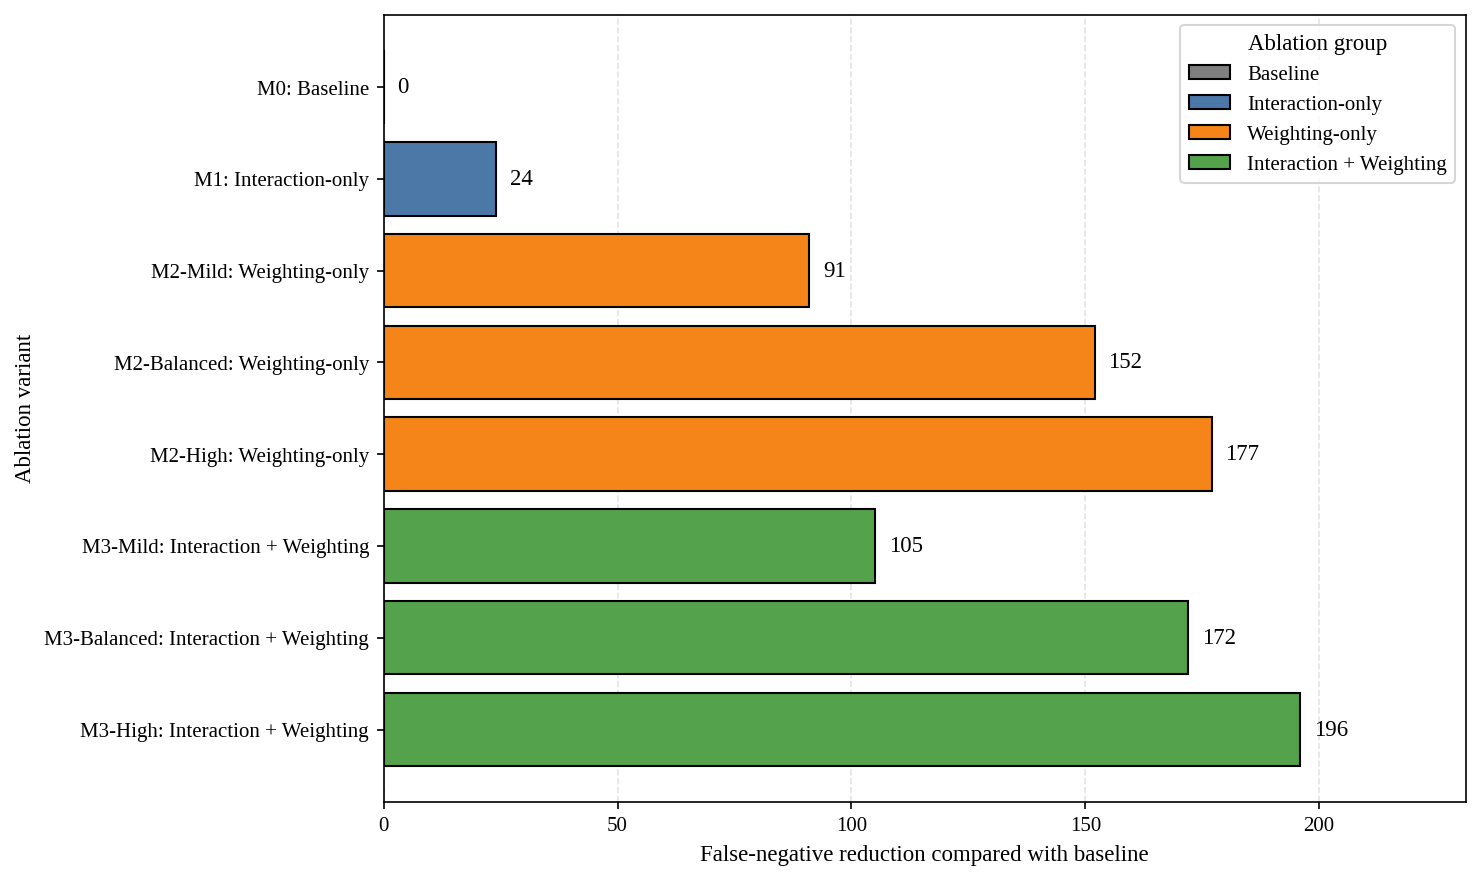

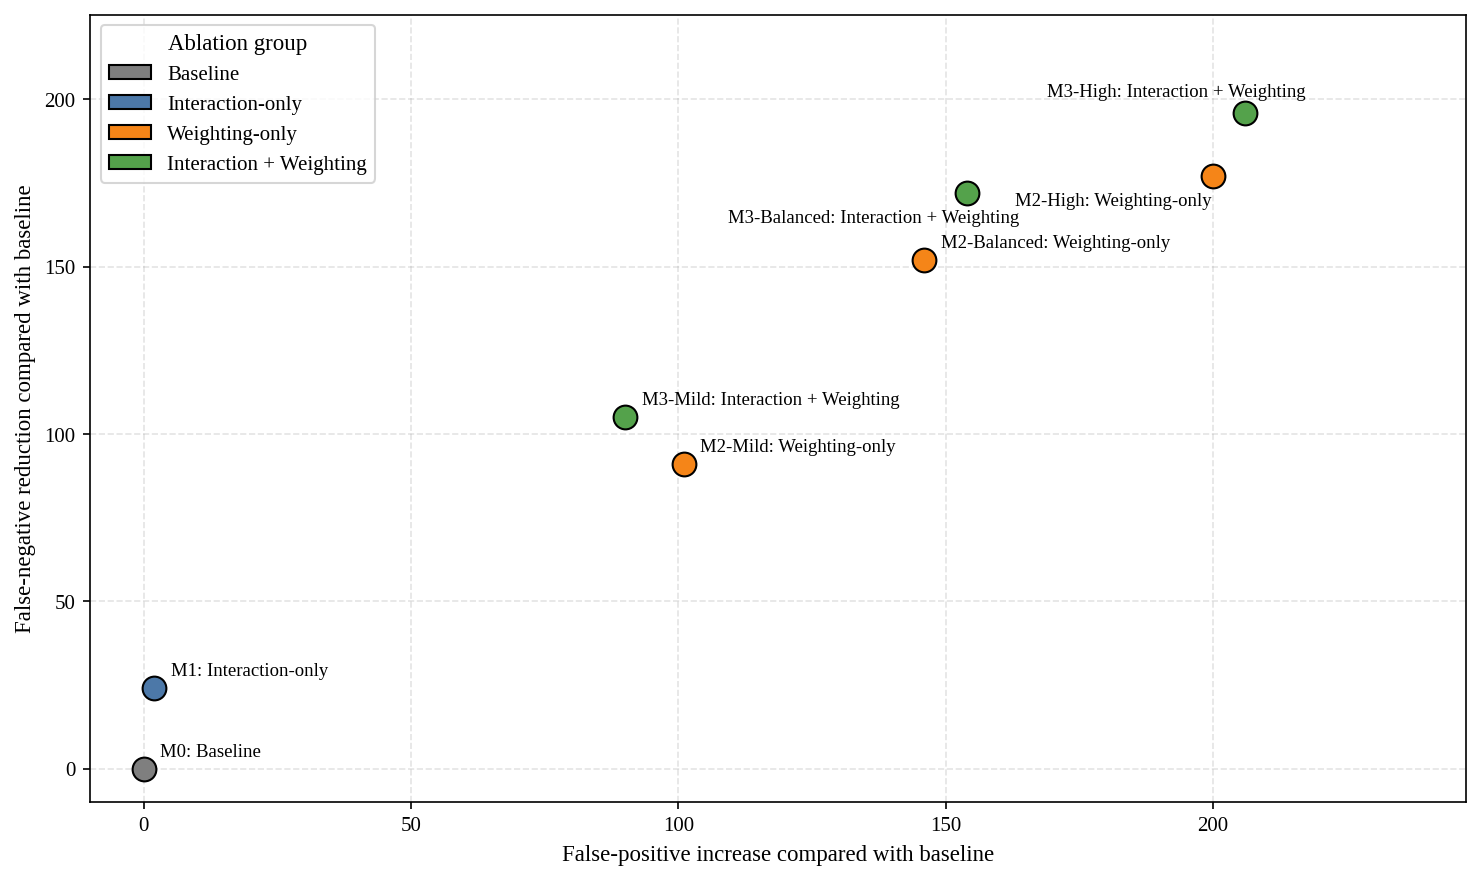

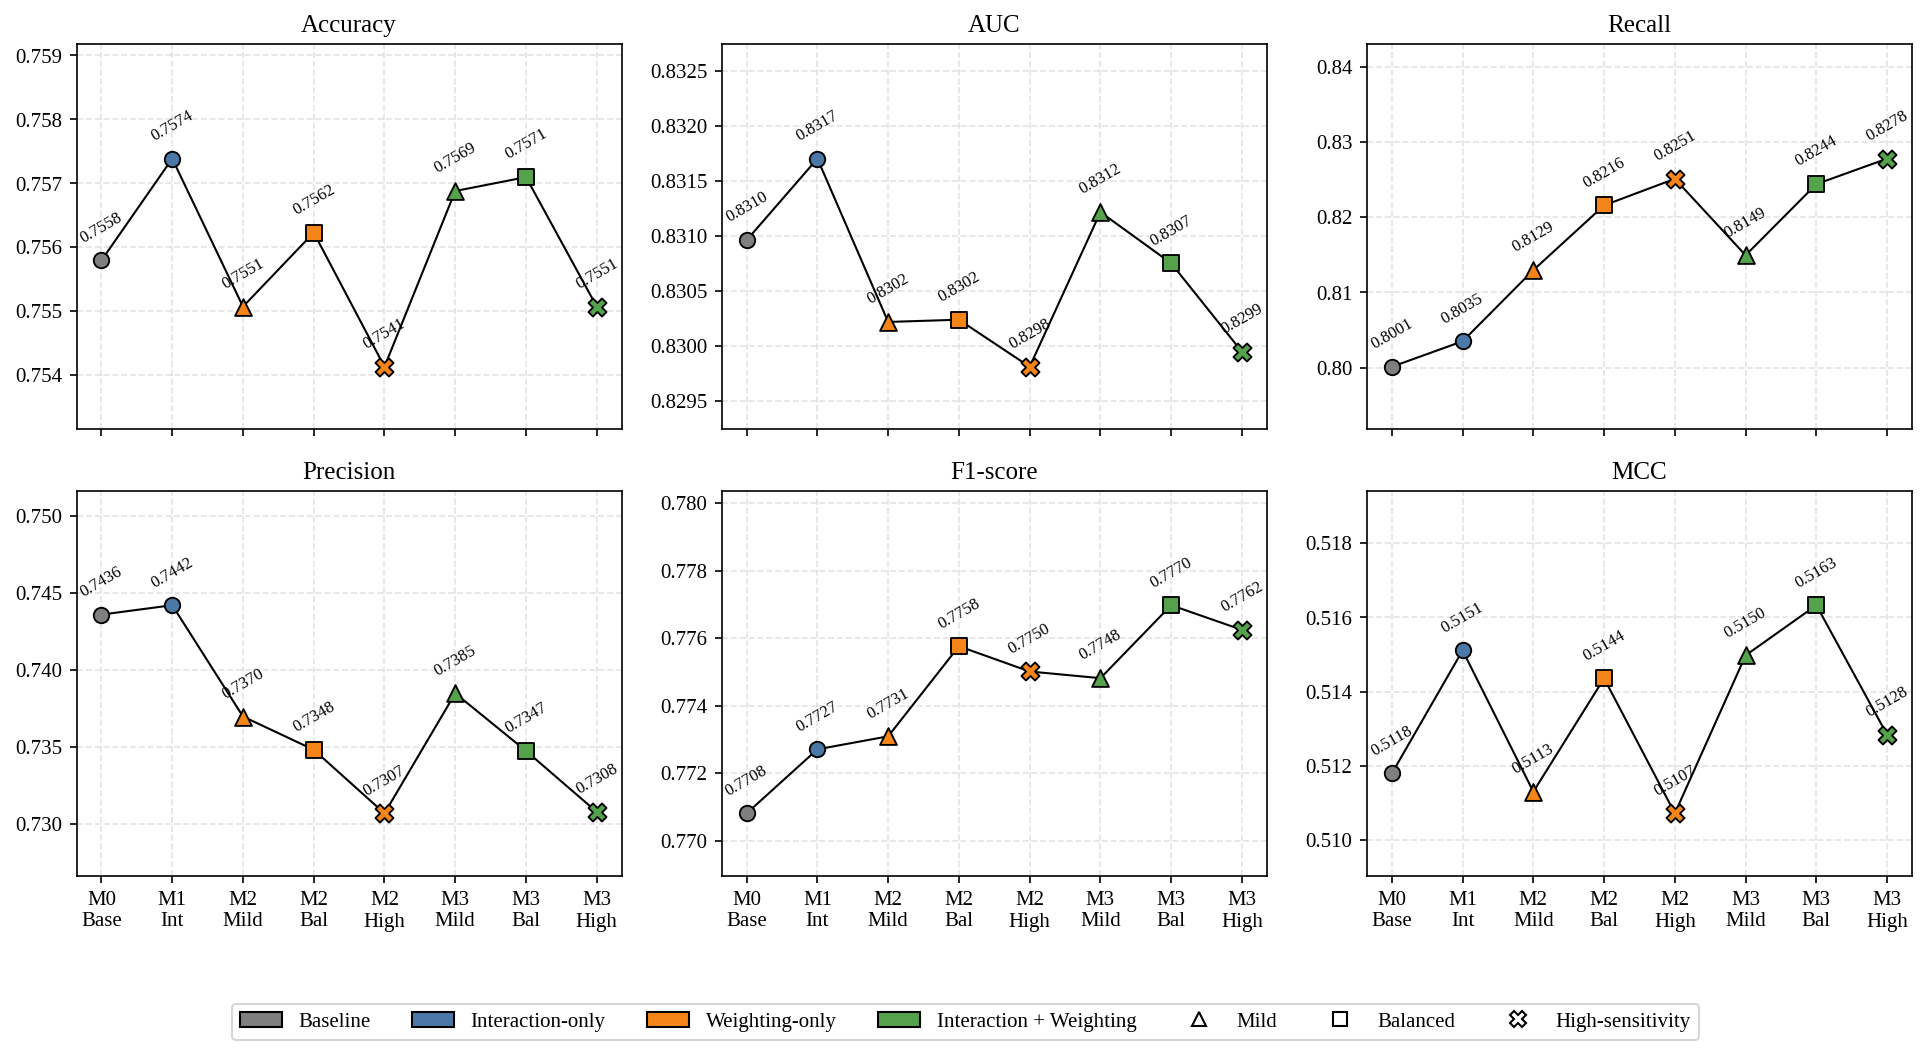

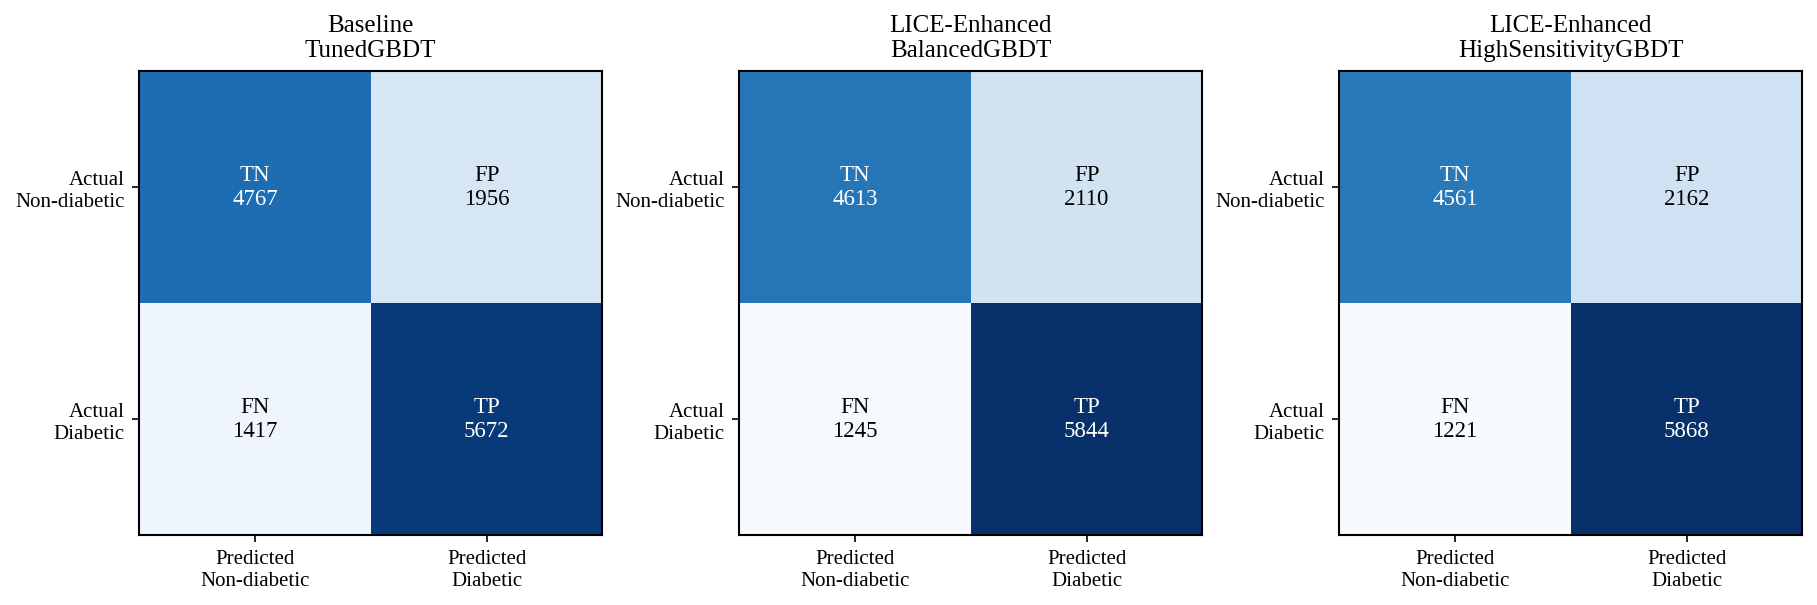

Figures 2-5 regenerated.


In [4]:
"""Replacement code for Section 4 of 04_Result_Tables_and_Figures.ipynb."""

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research/"
    "LICE_Guided_Model_Refinement_Release_V3"
)
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = PROJECT_ROOT / "generated_outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(
    RESULTS_DIR / "metrics_full_precision.csv"
).set_index("Model")
comparison = pd.read_csv(
    RESULTS_DIR / "comparison_vs_baseline_full_precision.csv"
).set_index("Model")

MODEL_ORDER = [
    "Baseline", "M1-Interactions", "M2-Mild", "M2-Balanced",
    "M2-High", "M3-Mild", "M3-Balanced", "M3-High",
]

available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}
if "Times New Roman" in available_fonts:
    selected_font = "Times New Roman"
elif "Liberation Serif" in available_fonts:
    selected_font = "Liberation Serif"
else:
    selected_font = "DejaVu Serif"

print(f"Plot font: {selected_font}")

plt.rcParams.update({
    "font.family": selected_font,
    "font.size": 11,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
})


def save_figure(figure, number, slug):
    stem = f"figure_{number}_{slug}"
    figure.savefig(
        FIGURE_DIR / f"{stem}.svg", bbox_inches="tight", dpi=1400
    )
    figure.savefig(
        FIGURE_DIR / f"{stem}.png", bbox_inches="tight", dpi=300
    )
    plt.show()
    plt.close(figure)
    return stem


short_labels = [
    "M0: Baseline", "M1: Interaction-only", "M2-Mild: Weighting-only",
    "M2-Balanced: Weighting-only", "M2-High: Weighting-only",
    "M3-Mild: Interaction + Weighting",
    "M3-Balanced: Interaction + Weighting",
    "M3-High: Interaction + Weighting",
]
metric_short_labels = [
    "M0\nBase", "M1\nInt", "M2\nMild", "M2\nBal",
    "M2\nHigh", "M3\nMild", "M3\nBal", "M3\nHigh",
]
group_colors = [
    "#7f7f7f", "#4c78a8", "#f58518", "#f58518",
    "#f58518", "#54a24b", "#54a24b", "#54a24b",
]
group_legend_handles = [
    Patch(facecolor="#7f7f7f", edgecolor="black", label="Baseline"),
    Patch(facecolor="#4c78a8", edgecolor="black", label="Interaction-only"),
    Patch(facecolor="#f58518", edgecolor="black", label="Weighting-only"),
    Patch(
        facecolor="#54a24b",
        edgecolor="black",
        label="Interaction + Weighting",
    ),
]

plot_data = comparison.loc[MODEL_ORDER].copy()

# Figure 2
figure_2, axis = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(MODEL_ORDER))
bars = axis.barh(
    y_positions,
    plot_data.FN_Reduction,
    color=group_colors,
    edgecolor="black",
    linewidth=1.0,
)
axis.set_yticks(y_positions, short_labels)
axis.invert_yaxis()
max_fn_reduction = float(plot_data.FN_Reduction.max())
axis.set_xlim(0, max_fn_reduction * 1.18)
label_offset = max_fn_reduction * 0.015
for bar in bars:
    value = bar.get_width()
    axis.text(
        value + label_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center",
        ha="left",
    )
axis.set_xlabel("False-negative reduction compared with baseline")
axis.set_ylabel("Ablation variant")
axis.grid(axis="x", linestyle="--", alpha=0.35)
axis.set_axisbelow(True)
axis.legend(
    handles=group_legend_handles,
    title="Ablation group",
    loc="upper right",
    frameon=True,
)
figure_2.tight_layout()
save_figure(figure_2, 2, "false_negative_reduction")

# Figure 3
figure_3, axis = plt.subplots(figsize=(10, 6))
for index, model in enumerate(MODEL_ORDER):
    row = plot_data.loc[model]
    axis.scatter(
        row.FP_Increase,
        row.FN_Reduction,
        s=130,
        marker="o",
        color=group_colors[index],
        edgecolor="black",
        linewidth=1.0,
    )
    if model == "M3-High":
        offset = (-95, 8)
    elif model == "M3-Balanced":
        offset = (-115, -14)
    elif model == "M2-High":
        offset = (-95, -14)
    else:
        offset = (8, 6)
    axis.annotate(
        short_labels[index],
        (row.FP_Increase, row.FN_Reduction),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
    )
axis.set_xlabel("False-positive increase compared with baseline")
axis.set_ylabel("False-negative reduction compared with baseline")
axis.set_xlim(-10, float(plot_data.FP_Increase.max()) * 1.20)
axis.set_ylim(-10, max_fn_reduction * 1.15)
axis.grid(linestyle="--", alpha=0.35)
axis.set_axisbelow(True)
axis.legend(
    handles=group_legend_handles,
    title="Ablation group",
    loc="upper left",
    frameon=True,
)
figure_3.tight_layout()
save_figure(figure_3, 3, "fn_fp_tradeoff")

# Figure 4
metric_names = [
    ("Accuracy", "Accuracy"),
    ("AUC", "AUC"),
    ("Recall", "Recall"),
    ("Precision", "Precision"),
    ("F1", "F1-score"),
    ("MCC", "MCC"),
]
configuration = [
    "Baseline", "Interaction-only", "Mild", "Balanced",
    "High-sensitivity", "Mild", "Balanced", "High-sensitivity",
]
marker_map = {
    "Baseline": "o",
    "Interaction-only": "o",
    "Mild": "^",
    "Balanced": "s",
    "High-sensitivity": "X",
}
marker_size_map = {
    "Baseline": 55,
    "Interaction-only": 55,
    "Mild": 65,
    "Balanced": 60,
    "High-sensitivity": 75,
}

figure_4, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
x_positions = np.arange(len(MODEL_ORDER))
for axis, (metric, metric_title) in zip(axes.ravel(), metric_names):
    values = metrics.loc[MODEL_ORDER, metric].to_numpy()
    axis.plot(x_positions, values, color="black", linewidth=1.0, zorder=1)
    for index, value in enumerate(values):
        axis.scatter(
            x_positions[index],
            value,
            color=group_colors[index],
            edgecolor="black",
            marker=marker_map[configuration[index]],
            s=marker_size_map[configuration[index]],
            linewidth=0.9,
            zorder=3,
        )
        axis.annotate(
            f"{value:.4f}",
            (x_positions[index], value),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=30,
            clip_on=False,
        )
    axis.set_title(metric_title)
    axis.grid(linestyle="--", alpha=0.35)
    axis.set_axisbelow(True)
    y_min, y_max = float(values.min()), float(values.max())
    y_range = y_max - y_min if y_max > y_min else 0.01
    axis.set_ylim(y_min - 0.30 * y_range, y_max + 0.55 * y_range)
    axis.set_xticks(x_positions, metric_short_labels)

marker_legend_handles = [
    Line2D(
        [0], [0], marker="^", color="black", label="Mild",
        markerfacecolor="white", linestyle="None", markersize=7,
    ),
    Line2D(
        [0], [0], marker="s", color="black", label="Balanced",
        markerfacecolor="white", linestyle="None", markersize=7,
    ),
    Line2D(
        [0], [0], marker="X", color="black", label="High-sensitivity",
        markerfacecolor="white", linestyle="None", markersize=8,
    ),
]
figure_4.legend(
    handles=group_legend_handles + marker_legend_handles,
    loc="lower center",
    ncol=7,
    frameon=True,
    bbox_to_anchor=(0.5, -0.01),
)
figure_4.tight_layout(rect=[0, 0.08, 1, 1])
save_figure(figure_4, 4, "performance_trends")

# Figure 5
confusion_models = ["Baseline", "M3-Balanced", "M3-High"]
confusion_titles = [
    "Baseline\nTunedGBDT",
    "LICE-Enhanced\nBalancedGBDT",
    "LICE-Enhanced\nHighSensitivityGBDT",
]
cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
x_tick_labels = ["Predicted\nNon-diabetic", "Predicted\nDiabetic"]
y_tick_labels = ["Actual\nNon-diabetic", "Actual\nDiabetic"]

matrices = []
for model in confusion_models:
    row = metrics.loc[model]
    matrices.append(
        np.array([[row.TN, row.FP], [row.FN, row.TP]], dtype=int)
    )
all_values = np.concatenate([matrix.ravel() for matrix in matrices])
vmin, vmax = int(all_values.min()), int(all_values.max())
text_threshold = (vmin + vmax) / 2.0

figure_5, axes = plt.subplots(
    1, 3, figsize=(12, 4), constrained_layout=True
)
for axis, matrix, title in zip(axes, matrices, confusion_titles):
    axis.imshow(matrix, cmap="Blues", vmin=vmin, vmax=vmax)
    axis.set_xticks([0, 1], x_tick_labels)
    axis.set_yticks([0, 1], y_tick_labels)
    axis.set_title(title, pad=7)
    for row_index in range(2):
        for column_index in range(2):
            value = matrix[row_index, column_index]
            axis.text(
                column_index,
                row_index,
                f"{cell_labels[row_index, column_index]}\n{value}",
                ha="center",
                va="center",
                color="white" if value > text_threshold else "black",
                fontsize=11,
            )
    for spine in axis.spines.values():
        spine.set_linewidth(1.0)
save_figure(figure_5, 5, "confusion_matrix_comparison")

print("Figures 2-5 regenerated.")


## 5. Output manifest and checks


In [5]:
manifest = {
    "tables": table_files,
    "figures": [
        "figure_2_false_negative_reduction",
        "figure_3_fn_fp_tradeoff",
        "figure_4_performance_trends",
        "figure_5_confusion_matrix_comparison",
    ],
    "internal_table_source": (
        "results/metrics_full_precision.csv, "
        "results/comparison_vs_baseline_full_precision.csv, and "
        "results/mcnemar_results_full_precision.csv"
    ),
    "external_table_10_source": (
        "reference_inputs/published_gbc_reference.csv"
    ),
    "rounding": {
        "performance_metrics_and_deltas": "four decimal places",
        "relative_FN_and_percentage_point_differences": "two decimal places",
        "calculation_policy": (
            "all differences calculated from unrounded inputs before "
            "presentation rounding"
        ),
    },
    "figure_1": "Conceptual framework diagram; separate editable source",
}

with (GENERATED_DIR / "generation_manifest.json").open("w") as stream:
    json.dump(manifest, stream, indent=2)

expected_table_files = [
    TABLE_DIR / f"{stem}.{extension}"
    for stem in table_files
    for extension in ("csv", "md")
]
expected_figure_files = [
    FIGURE_DIR / f"figure_{number}_{slug}.{extension}"
    for number, slug in [
        (2, "false_negative_reduction"),
        (3, "fn_fp_tradeoff"),
        (4, "performance_trends"),
        (5, "confusion_matrix_comparison"),
    ]
    for extension in ("svg", "png")
]

assert all(path.exists() for path in expected_table_files)
assert all(path.exists() for path in expected_figure_files)

print("Tables 3-10 and Figures 2-5 regenerated successfully.")
print(f"Table files: {len(expected_table_files)}")
print(f"Figure files: {len(expected_figure_files)}")


Tables 3-10 and Figures 2-5 regenerated successfully.
Table files: 16
Figure files: 8
